In [9]:
%pip install qiskit==1.2.4
%pip install qiskit-aer==0.15.1
%pip install pylatexenc==2.10
%pip install qutip

from qiskit import QuantumCircuit
from qiskit.converters import circuit_to_gate
from qiskit.visualization import array_to_latex
from qiskit.quantum_info import Operator
from qiskit.quantum_info import Statevector
from qiskit import transpile
from qiskit.providers.basic_provider import BasicSimulator
from qiskit.visualization import plot_histogram
from qiskit.circuit import ControlledGate
import math

In [10]:
from qiskit import QuantumCircuit, transpile
from qiskit.providers.basic_provider import BasicSimulator
from qiskit.visualization import plot_histogram
from IPython.display import display
import qutip as qt

def get_quantum_random_bits(num_bits):
    """Generates true random bits via quantum superposition."""
    qc = QuantumCircuit(num_bits, num_bits)
    qc.h(range(num_bits))
    qc.measure(range(num_bits), range(num_bits))

    simulator = BasicSimulator()
    t_qc = transpile(qc, simulator)
    result = simulator.run(t_qc, shots=1).result()
    return list(result.get_counts().keys())[0][::-1]

NUM_QUBITS = 8
print("Setup complete. Ready to begin BB84.")

Setup complete. Ready to begin BB84.


## Phase 1: Protocol Initialization

The protocol begins with Alice and Bob independently generating true random sequences.
* **Alice's Bits:** The actual message/key she wants to send (0s and 1s).
* **Alice's Bases:** The polarization filters she will use to encode her bits. She randomly chooses between the **Rectilinear basis** (0) and the **Diagonal basis** (1).
* **Bob's Bases:** Bob does not know what bases Alice used, so he must randomly guess which filters to apply when he receives the photons.

In [11]:
# --- PHASE 1: PROTOCOL INITIALIZATION ---

alice_bits = get_quantum_random_bits(NUM_QUBITS)
alice_bases = get_quantum_random_bits(NUM_QUBITS)
bob_bases = get_quantum_random_bits(NUM_QUBITS)

print(f"Alice's Raw Bits:      {alice_bits}")
print(f"Alice's Encoding Bases:{alice_bases} (0=Rectilinear, 1=Diagonal)")
print(f"Bob's Measuring Bases: {bob_bases} (0=Rectilinear, 1=Diagonal)")

Alice's Raw Bits:      01000001
Alice's Encoding Bases:01111010 (0=Rectilinear, 1=Diagonal)
Bob's Measuring Bases: 10100100 (0=Rectilinear, 1=Diagonal)


## Phase 2: Physical Encoding Dictionary

Using QuTiP, we can visualize these four physical states on the **Bloch Sphere**:
* **Rectilinear Basis (Z-axis):** Bit `0` is vertically polarized (North Pole), and Bit `1` is horizontally polarized (South Pole).
* **Diagonal Basis (X-axis):** Applying a Hadamard gate rotates the photon by 45 degrees. Bit `0` becomes $+45^\circ$ (Front Equator), and Bit `1` becomes $-45^\circ$ (Back Equator).

This geometric orthogonality (90 degrees apart on the sphere) is the core security mechanism of BB84.

Visualizing the 4 possible physical photon polarizations on the Bloch Sphere:
  • Rectilinear Basis (Z-axis): |0> (Vertical) and |1> (Horizontal)
  • Diagonal Basis (X-axis): |+> (+45°) and |-> (-45°)



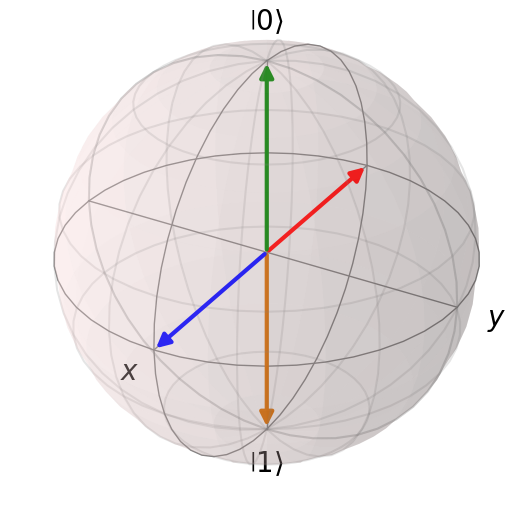

None

In [12]:
# --- PHASE 2: PHYSICAL ENCODING DICTIONARY ---

print("Visualizing the 4 possible physical photon polarizations on the Bloch Sphere:")
print("  • Rectilinear Basis (Z-axis): |0> (Vertical) and |1> (Horizontal)")
print("  • Diagonal Basis (X-axis): |+> (+45°) and |-> (-45°)\n")

basis_0 = qt.basis(2, 0)
basis_1 = qt.basis(2, 1)

photon_0_rect = basis_0                       # |0> (North Pole)
photon_1_rect = basis_1                       # |1> (South Pole)
photon_0_diag = (basis_0 + basis_1).unit()    # |+> (Equator +X)
photon_1_diag = (basis_0 - basis_1).unit()    # |-> (Equator -X)

b = qt.Bloch()
b.add_states([photon_0_rect, photon_1_rect, photon_0_diag, photon_1_diag])
display(b.show())

## Phase 3: Quantum State Preparation & Transmission

Alice now prepares her qubits based on her random sequences.
1. If her bit is a `1`, she applies an `X` gate (flipping the state from $|0\rangle$ to $|1\rangle$).
2. If her chosen basis is Diagonal (`1`), she applies an `H` (Hadamard) gate, rotating the state to the X-axis of the Bloch sphere.

Once prepared, she sends the photons through the quantum channel (e.g., a fiber optic cable). In our Qiskit circuit, this transmission is represented by a visual `barrier()`.

In [13]:
# --- PHASE 3: ENCODING & TRANSMISSION ---

# Initialize the shared quantum circuit
qc = QuantumCircuit(NUM_QUBITS, NUM_QUBITS)

# Alice prepares her states
for i in range(NUM_QUBITS):
    if alice_bits[i] == '1':
        qc.x(i) # Flip state to |1>
    if alice_bases[i] == '1':
        qc.h(i) # Rotate to Diagonal basis

# A barrier represents the qubits traveling across the quantum link
qc.barrier()

print("Alice has encoded the qubits and transmitted them over the quantum channel.")

Alice has encoded the qubits and transmitted them over the quantum channel.


## Phase 4: Bob's Measurement

Bob receives the photons. Because he cannot clone or safely "peek" at the quantum states without altering them, he must blindly apply his randomly generated measurement bases.
* If he guesses the **Diagonal** basis (`1`), he applies an `H` gate to align the photon with his measurement apparatus before reading it.
* If he guesses correctly, he reads Alice's exact bit. If he guesses wrong, the photon's state collapses randomly, yielding a 50/50 result.

We then execute the circuit on a quantum simulator to get Bob's raw measurement results.

Quantum Circuit (Alice -> Channel -> Bob):


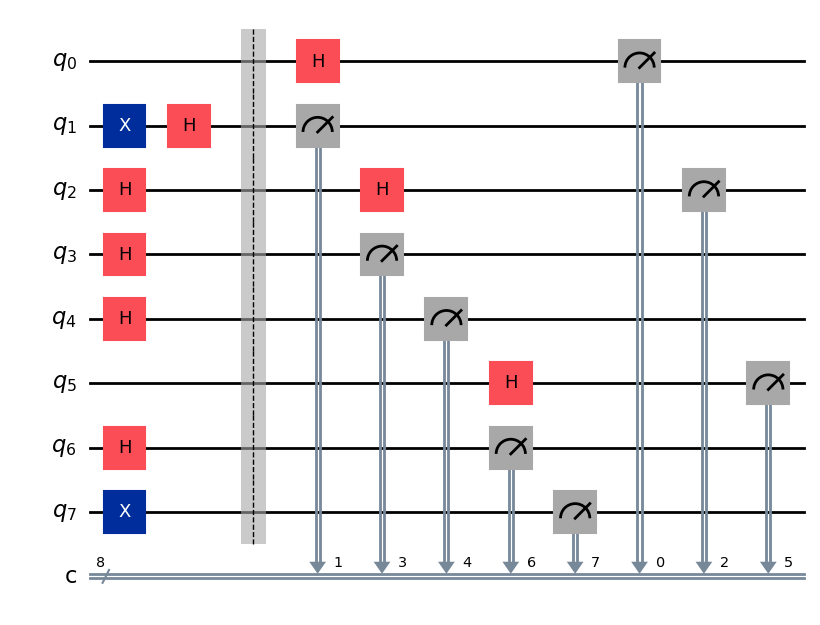


Bob's Raw Measurement Results:


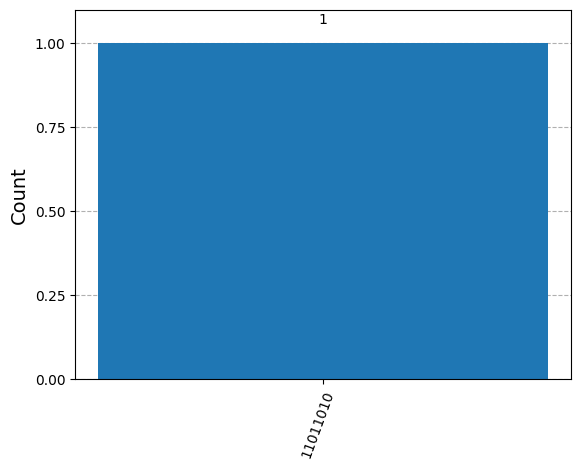

Bob's Raw Bits:        01011011


In [14]:
# --- PHASE 4: MEASUREMENT ---

# Bob applies his measurement bases
for i in range(NUM_QUBITS):
    if bob_bases[i] == '1':
        qc.h(i) # Rotate basis before measuring
    qc.measure(i, i)

# Display the full circuit
print("Quantum Circuit (Alice -> Channel -> Bob):")
display(qc.draw("mpl"))

# Execute the circuit on the simulator
simulator = BasicSimulator()
t_qc = transpile(qc, simulator)
result = simulator.run(t_qc, shots=1).result()

# Extract Bob's measured bits
bob_bits = list(result.get_counts().keys())[0][::-1]

print("\nBob's Raw Measurement Results:")
display(plot_histogram(result.get_counts()))
print(f"Bob's Raw Bits:        {bob_bits}")

## Phase 5: Key Sifting (Reconciliation)

Now that the quantum transmission is over, Alice and Bob communicate over a standard, public, authenticated classical channel (like a regular internet connection).

**Crucially, they do not share their bits.** They only share the **bases** they used. They iterate through their sequences and discard any bits where their bases did not match. Because they guessed independently, they will discard roughly 50% of the transmission. The remaining bits form the "Sifted Key."

In [15]:
# --- PHASE 5: KEY SIFTING ---

alice_key = []
bob_key = []

# Both sides keep only the qubits where the bases match
for i in range(NUM_QUBITS):
    if alice_bases[i] == bob_bases[i]:
        alice_key.append(alice_bits[i])
        bob_key.append(bob_bits[i])

print(f"Sifted Key Length: {len(alice_key)} bits")
print(f"Alice's Sifted Key: {''.join(alice_key)}")
print(f"Bob's Sifted Key:   {''.join(bob_key)}")

Sifted Key Length: 2 bits
Alice's Sifted Key: 01
Bob's Sifted Key:   01


## Phase 6: Error Estimation & Verification

In an ideal, noiseless scenario, Alice and Bob's sifted keys should match perfectly (0% error rate).

To ensure the channel was secure, they calculate the error rate between their sifted keys. If the error rate is below our safety threshold (10%), they can be mathematically certain that no eavesdropper was listening, and the key is secure to use!

In [16]:
# --- PHASE 6: ERROR ESTIMATION ---

# Calculate errors between the two sifted keys
errors = sum(1 for a, b in zip(alice_key, bob_key) if a != b)
error_rate = errors / len(alice_key) if len(alice_key) > 0 else 0

print(f"Error Rate: {error_rate * 100:.2f}%\n")

if error_rate > 0.10:
    print("❌ ALERT: High error rate detected! The channel may be compromised by an eavesdropper.")
else:
    print("✅ SUCCESS: Keys match securely. No attack detected.")
    print(f"Final Secure Key: {''.join(alice_key)}")

Error Rate: 0.00%

✅ SUCCESS: Keys match securely. No attack detected.
Final Secure Key: 01
